## Desarrollo tarea HW Sesión 7

Felipe López Vergara

In [22]:
import yfinance as yf
import numpy as np
import pandas as pd
import seaborn as sns 
import warnings
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.simplefilter("ignore")

## Clustering y Reducción de Dimensionalidad en un Portafolio de Inversiones.

Para lo siguiente, tome 50 series de precios de acciones (5 años de historia, frecuencia diaria) que están disponibles en yfinance y realice lo siguiente.

En la siguiente tabla muestra las 50 acciones consideradas para el portafolio:

| Nº | Ticker | Nombre Compañía | Descripción |
| :--- | :--- | :--- | :--- |
| 1 | PLTR | Palantir Technologies Inc. | Empresa de software y análisis de datos. |
| 2 | HAS | Hasbro, Inc. | Fabricante de juguetes y productos de entretenimiento.. |
| 3 | PG | Procter & Gamble Company (La) | Fabricante de productos de consumo masivo. |
| 4 | NVDA | Corporación NVIDIA | Diseñador de procesadores gráficos y chips de IA. |
| 5 | NOK | Nokia Oyj | Empresa de telecomunicaciones y redes. |
| 6 | INTC | Corporación Intel | Fabricante de semiconductores y procesadores. |
| 7 | GT | The Goodyear Tire & Rubber Company | Fabricante de neumáticos y productos de caucho. |
| 8 | ONDS | Ondas Inc. | Desarrollador de soluciones de comunicación inalámbrica. |
| 9 | AMZN | Amazon.com, Inc. | Empresa de comercio electrónico y servicios en la nube. |
| 10 | QSR | Restaurant Brands International Inc | Operador de cadenas internacionales de restaurantes. |
| 11 | CIFR | Cipher Digital Inc. | Empresa de minería de criptomonedas. |
| 12 | SOFI | SoFi Technologies, Inc. | Empresa de servicios financieros digitales. |
| 13 | AAL | Grupo American Airlines Inc. | Aerolínea de transporte de pasajeros y carga. |
| 14 | PFE | Pfizer Inc. | Compañía farmacéutica y biotecnológica. |
| 15 | MCD | McDonald's Corporation | Cadena internacional de restaurantes de comida rápida. |
| 16 | CMG | Chipotle Mexican Grill, Inc. | Cadena de restaurantes de comida mexicana. |
| 17 | SMCI | Super Micro Computer, Inc. | Fabricante de servidores y soluciones informáticas. |
| 18 | AAPL | Apple Inc. | Empresa de tecnología y electrónica de consumo. |
| 19 | F | Compañía Ford Motor | Fabricante de automóviles y vehículos comerciales. |
| 20 | ADDYY | Adidas AG. | Fabricante de ropa, calzado y artículos deportivos. |
| 21 | NVO | Novo Nordisk A/S | Compañía farmacéutica especializada en diabetes. |
| 22 | PINS | Pinterest, Inc. | Plataforma de redes sociales e inspiración visual. |
| 23 | UBER | Uber Technologies, Inc. | Plataforma de transporte y entrega a domicilio. |
| 24 | T | AT&T Inc. | Empresa de telecomunicaciones y servicios móviles. |
| 25 | AMC | AMC Entertainment Holdings, Inc. | Operador de cadenas de salas de cine. |
| 26 | JBLU | Corporación JetBlue Airways | Aerolínea comercial de bajo costo. |
| 27 | MSFT | Corporación Microsoft | Empresa de software, nube y tecnología. |
| 28 | ORCL | Corporación Oracle | Proveedor de software empresarial y bases de datos. |
| 29 | JPM | JPMorgan Chase & Co. | Banco de inversión y servicios financieros. |
| 30 | META | Meta Platforms, Inc. | Empresa de tecnología y redes sociales. |
| 31 | QXO | QXO, Inc. | Empresa de distribución de materiales para la construcción. |
| 32 | RIG | Transocean Ltd. | Proveedor de servicios de perforación petrolera offshore. |
| 33 | AMD | Dispositivos Micro Avanzados, Inc. | Fabricante de procesadores y chips gráficos. |
| 34 | EQT | EQT Corporation | Productor de gas natural. |
| 35 | NFLX | Netflix, Inc. | Plataforma de entretenimiento por streaming. |
| 36 | NKE | Nike, Inc | Fabricante de ropa, calzado y artículos deportivos. |
| 37 | HL | Compañía minera Hecla | Empresa dedicada a la minería de metales preciosos. |
| 38 | WU | La compañía Western Union | Empresa de transferencias internacionales de dinero. |
| 39 | CDE | Coeur Mining, Inc. | Productor de oro y plata. |
| 40 | UNP | Union Pacific Corporation | Empresa de transporte ferroviario de carga. |
| 41 | WMT | Walmart Inc. | Cadena minorista de supermercados y grandes almacenes. |
| 42 | ABEV | Ambev S.A. | Productor de bebidas y cerveza. |
| 43 | PEP | PepsiCo, Inc. | Fabricante de alimentos y bebidas. |
| 44 | MU | Micron Technology, Inc. | Fabricante de semiconductores y memorias. |
| 45 | TSLA | Tesla, Inc. | Fabricante de vehículos eléctricos y soluciones energéticas. |
| 46 | GM | General Motors Company | Fabricante de automóviles. |
| 47 | CLH | Clean Harbors | Proveedor de servicios ambientales y gestión de residuos. |
| 48 | GOOGL | Alphabet Inc. | Empresa de tecnología y servicios de internet. |
| 49 | ACHR | Archer Aviation Inc. | Desarrollador de aeronaves eléctricas de despegue vertical. |
| 50 | BAC | Bank of America | Banco comercial y de servicios financieros. |

In [29]:
# Descarga Series Históricas

# Conjunto de Tickers para construir el Portafolio
tickers = ['PLTR','HAS','PG','NVDA','NOK','INTC','GT','ONDS',
'AMZN','QSR','CIFR','SOFI','AAL','PFE','MCD','CMG','SMCI','AAPL',
'F','ADDYY','NVO','PINS','UBER','T','AMC','JBLU','MSFT','ORCL','JPM',
'META','QXO','RIG','AMD','EQT','NFLX','NKE','HL','WU','CDE','UNP',
'WMT','ABEV','PEP','MU','TSLA','GM','CLH','GOOGL','ACHR','BAC']

# Ordeno los Tickers 
tickers.sort()

# Guardo el total de Tickers 
n = len(tickers)

start = '2021-01-01' # fecha inicio 
end = '2025-12-31'   # fecha termino 

# Descarga de Series historias (Precios de Cierre)
data = yf.download(tickers, start = start, end = end)["Close"]


data.head()

[*********************100%***********************]  50 of 50 completed


Ticker,AAL,AAPL,ABEV,ACHR,ADDYY,AMC,AMD,AMZN,BAC,CDE,...,QXO,RIG,SMCI,SOFI,T,TSLA,UBER,UNP,WMT,WU
2021-01-04,15.13,125.740860,2.365816,10.09,169.457840,20.100000,92.300003,159.331497,26.327255,10.817852,...,18.133142,2.32,3.105,12.200000,15.334668,243.256668,51.139999,179.638412,45.454311,14.251034
2021-01-05,15.43,127.295456,2.421203,10.16,167.471268,19.799999,92.769997,160.925507,26.528898,10.967683,...,19.039799,2.65,3.116,12.150000,15.240914,245.036667,54.009998,181.841766,45.212353,14.467056
2021-01-06,15.52,123.010513,2.429116,10.15,168.389587,20.100000,90.330002,156.919006,28.185862,11.057583,...,19.039799,2.67,3.189,12.120000,15.537811,251.993332,52.480000,185.646744,45.494640,15.134771
2021-01-07,15.38,127.208038,2.365816,10.22,167.002747,20.500000,95.160004,158.108002,28.808311,10.987661,...,19.946455,2.77,3.219,19.139999,15.579481,272.013336,56.130001,188.230545,45.491531,14.964573
2021-01-08,15.13,128.305984,2.429116,10.37,169.673386,21.400000,94.580002,159.134995,28.518997,9.579243,...,20.248674,2.78,3.188,18.740000,15.472039,293.339996,53.279999,193.628281,45.485329,15.232956


Construya un resumen estadístico de los retornos extraídos con las siguientes medidas de tendencia central: media, mediana, desviación estándar, coeficiente de asimetría y kurtosis. Esto, se debe hacer por cada activo y el resultado debe ser un dataframe (piensen en crear una función de esto). Genere una categorización para los activos de acuerdo a tres niveles de volatilidad 
(baja, media, alta). Observación: gran parte de esto, lo tienen hecho en la tarea 1.

In [30]:
# Cálculos de retornos del DataFrame
retornos = data.pct_change().dropna()

# Resumen estadístico

def resumen_estadistico(retornos):

    resumen = pd.DataFrame({
        "Media": retornos.mean(),
        "Mediana": retornos.median(),
        "Desv_Estandar": retornos.std(),
        "Asimetria": retornos.skew(),
        "Kurtosis": retornos.kurt()
    })

    return resumen

# Crear dataframe
estadisticas = resumen_estadistico(retornos)
estadisticas.head()

,Media,Mediana,Desv_Estandar,Asimetria,Kurtosis
Ticker,,,,,
AAL,0.000466,0.000000,0.030321,0.488651,4.776991
AAPL,0.000771,0.001097,0.017558,0.453604,6.542338
ABEV,0.000225,0.000000,0.019488,0.247886,2.638686
ACHR,0.001123,-0.001011,0.052837,1.047245,4.984638
ADDYY,-0.000168,0.000000,0.023480,1.150514,13.633223


In [33]:
# Retornos de mercado (S&P 500) para el mismo periodo
sp500 = yf.download('^GSPC', start=start, end=end)
sp500 = sp500["Close"].squeeze()
retornos_mercado = sp500.pct_change().dropna()

# Cálculos de Betas

def calcular_beta(retornos, retornos_mercado):
    
    # Alinear fechas entre activo y mercado
    datos = pd.concat(
        [retornos, retornos_mercado],
        axis=1,
        join="inner"
    ).dropna()
    
    beta = (
        datos.iloc[:,0].cov(datos.iloc[:,1])
        /
        datos.iloc[:,1].var()
    )
    
    return beta

# Calcular beta para cada activo
betas = retornos.apply(lambda x: calcular_beta(x, retornos_mercado))

# Agregar beta al resumen estadístico
estadisticas["Beta"] = betas

# Clasificación volatilidad
def categoria_beta(beta):
    if beta < 0.8:
        return "Baja"
    elif beta <= 1.2:
        return "Media"
    else:
        return "Alta"

estadisticas["Nivel_Volatilidad"] = estadisticas["Beta"].apply(categoria_beta)
estadisticas

[*********************100%***********************]  1 of 1 completed


,Media,Mediana,Desv_Estandar,Asimetria,Kurtosis,Beta,Nivel_Volatilidad
Ticker,,,,,,,
AAL,0.000466,0.000000,0.030321,0.488651,4.776991,1.492630,Alta
AAPL,0.000771,0.001097,0.017558,0.453604,6.542338,1.244846,Alta
ABEV,0.000225,0.000000,0.019488,0.247886,2.638686,0.555465,Baja
ACHR,0.001123,-0.001011,0.052837,1.047245,4.984638,1.973245,Alta
ADDYY,-0.000168,0.000000,0.023480,1.150514,13.633223,1.134839,Media
AMC,0.002270,-0.004684,0.116118,14.634573,366.563536,0.990822,Media
AMD,0.001215,0.000000,0.033025,0.627410,4.977378,2.039725,Alta
AMZN,0.000546,0.000538,0.022122,0.143578,5.199136,1.484182,Alta
BAC,0.000729,0.000451,0.017048,-0.000397,3.286205,0.978938,Media


In [36]:
estadisticas["Nivel_Volatilidad"].value_counts()

Nivel_Volatilidad
Alta     24
Media    14
Baja     12
Name: count, dtype: int64

* * * Construya una matriz de correlaciones para las series descargadas. ¿ Qué puede decir al respecto ?

In [20]:
# Matriz de correlaciones
corr_matriz = retornos.corr()

# Mostrar matriz
corr_matriz

Ticker,AAL,AAPL,ABEV,ACHR,ADDYY,AMC,AMD,AMZN,BAC,CDE,...,QXO,RIG,SMCI,SOFI,T,TSLA,UBER,UNP,WMT,WU
Ticker,,,,,,,,,,,,,,,,,,,,,
AAL,1.000000,0.365414,0.183716,0.292872,0.339501,0.215981,0.376074,0.371733,0.463651,0.219829,...,0.082855,0.243387,0.189080,0.338617,0.146039,0.348379,0.395321,0.307735,0.144822,0.332665
AAPL,0.365414,1.000000,0.226398,0.262623,0.395241,0.122425,0.505213,0.561269,0.342203,0.192712,...,0.038575,0.205484,0.230600,0.341063,0.145331,0.500155,0.364445,0.359273,0.289756,0.303140
ABEV,0.183716,0.226398,1.000000,0.149439,0.255096,0.074308,0.155105,0.180513,0.244317,0.237449,...,0.038278,0.181139,0.088607,0.159523,0.184127,0.197005,0.178639,0.192038,0.134381,0.198991
ACHR,0.292872,0.262623,0.149439,1.000000,0.254898,0.079405,0.344723,0.310578,0.271476,0.198821,...,0.095405,0.141070,0.259475,0.388283,0.054111,0.340899,0.340459,0.205527,0.105662,0.173437
ADDYY,0.339501,0.395241,0.255096,0.254898,1.000000,0.057080,0.356105,0.383966,0.364957,0.266004,...,0.058749,0.136568,0.184691,0.276699,0.111767,0.264046,0.307906,0.310921,0.180856,0.256085
AMC,0.215981,0.122425,0.074308,0.079405,0.057080,1.000000,0.067098,0.091829,0.053189,0.028725,...,0.037671,0.284122,0.035972,0.144796,0.026183,0.123378,0.066828,0.018201,-0.025906,0.105692
AMD,0.376074,0.505213,0.155105,0.344723,0.356105,0.067098,1.000000,0.519827,0.299840,0.243656,...,0.058755,0.201678,0.439192,0.393738,0.000222,0.456643,0.433986,0.231914,0.130390,0.166272
AMZN,0.371733,0.561269,0.180513,0.310578,0.383966,0.091829,0.519827,1.000000,0.342171,0.235408,...,0.060909,0.187447,0.256585,0.388982,0.078904,0.448562,0.455004,0.279057,0.243392,0.209649
BAC,0.463651,0.342203,0.244317,0.271476,0.364957,0.053189,0.299840,0.342171,1.000000,0.226760,...,0.058707,0.337300,0.188047,0.333227,0.303991,0.306485,0.336073,0.484346,0.231355,0.387638


Movimiento en bloque del Sector Tecnológico (Big Tech):Existe una alta correlación entre las grandes empresas de tecnología y semiconductores (por ejemplo, NVDA y AMD con $0.70$, o MSFT y AMZN con $0.65$). Esto muestra que responden de forma conjunta a factores macroeconómicos como las tasas de interés.

Agrupación Sectorial (Clusters): Los activos de un mismo rubro tienden a moverse juntos debido a riesgos compartidos. Destacan la banca tradicional (JPM y BAC con $0.81$), la minería de metales preciosos (CDE y HL con $0.82$) y las aerolíneas (AAL y JBLU con $0.63$).

Activos Descorrelacionados y Defensivos: Acciones de consumo masivo como PG, PEP y WMT, así como empresas de telecomunicaciones (T), presentan correlaciones muy bajas o casi nulas con el sector tecnológico. Esto las convierte en instrumentos útiles para amortiguar la volatilidad en momentos de incertidumbre.

Casos Específicos o Aislados: Empresas como AMC o QXO registran correlaciones cercanas a cero con el resto del mercado. Esto indica que sus precios dependen de eventos corporativos particulares o especulaciones, más que del comportamiento general de la economía.

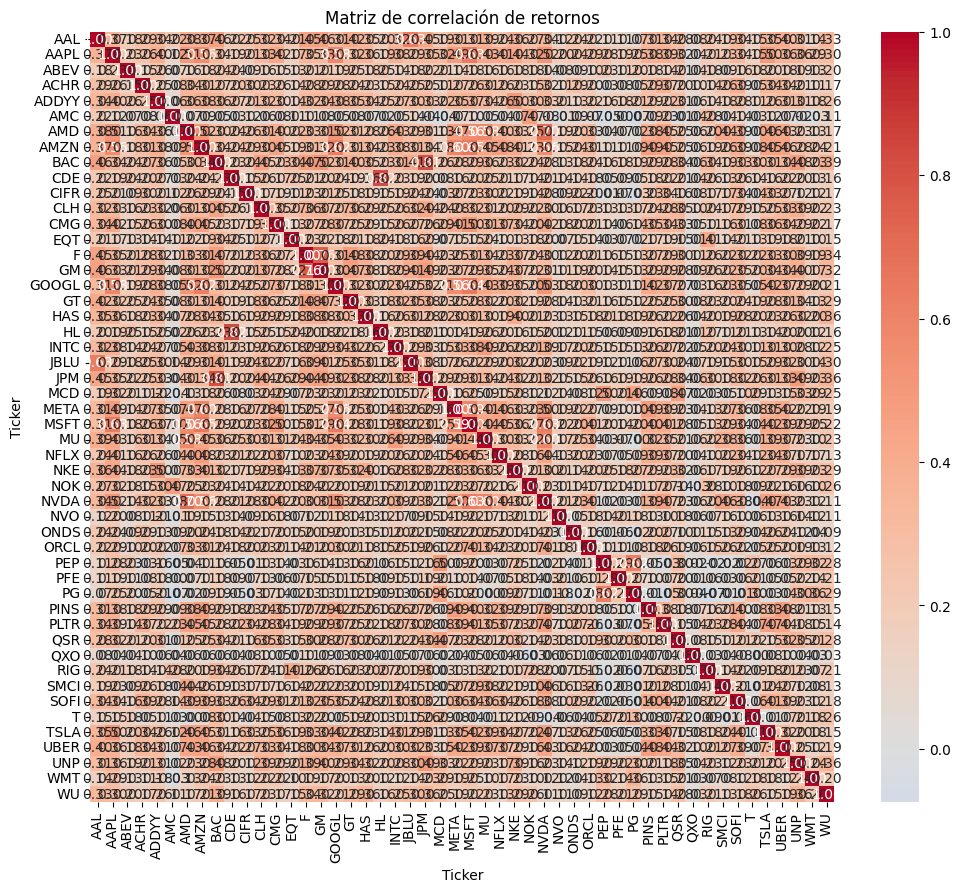

In [21]:
# Visualización de la matriz de correlación

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matriz,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("Matriz de correlación de retornos")
plt.show()

* * * Aplique PCA a la matriz de retornos con sólo dos componentes, y luego aplique clustering mediante KMeans, DBSCAN y cluster Jerárquicos. Visualize los conglomerados creados en la proyección mediante PCA. ¿ Qué conglomerados se aprecian ?, describa los conglomerados encontrados (es decir, que atributos tienen las series que permitan perfilar a los inversionistas que optan por estos activos).

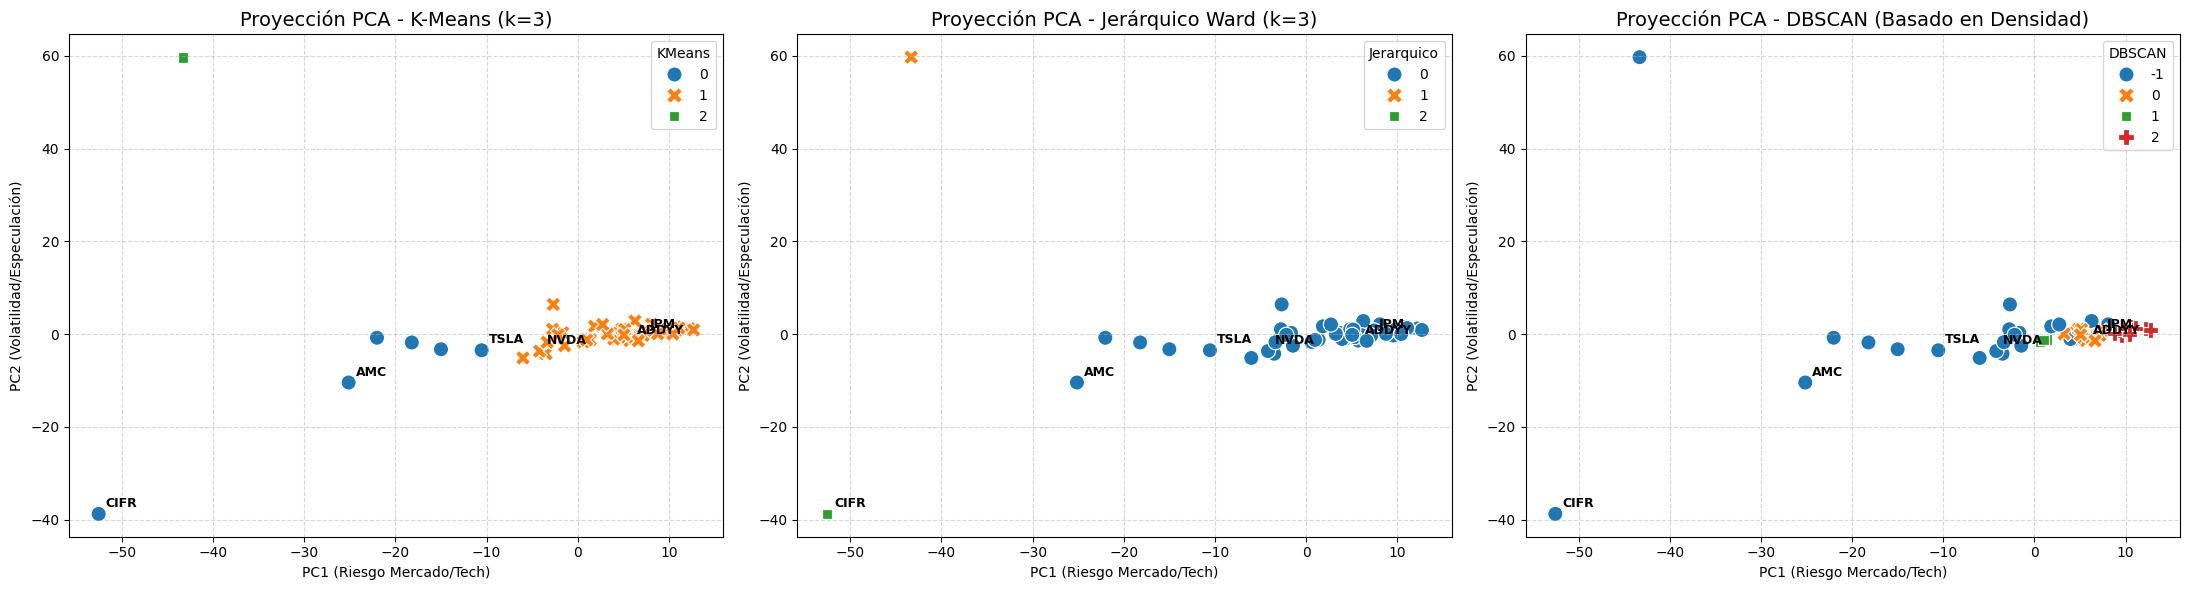

In [26]:
# 1. 'retornos' es el DataFrame 

X = retornos.T.values
tickers = retornos.columns

# 2. Estandarización de las series
X_scaled = StandardScaler().fit_transform(X)

# 3. Aplicación de PCA (2 Componentes Principales)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(
    X_pca, columns=["PC1 (Riesgo Mercado/Tech)", "PC2 (Volatilidad/Especulación)"], index=tickers
)

# 4. Algoritmos de Clustering sobre la proyección PCA
# A) K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_pca["KMeans"] = kmeans.fit_predict(X_pca)

# B) Cluster Jerárquico (Agglomerative)
hierarchical = AgglomerativeClustering(n_clusters=3)
df_pca["Jerarquico"] = hierarchical.fit_predict(X_pca)

# C) DBSCAN (Detecta densidad y ruido/outliers)
dbscan = DBSCAN(eps=1.2, min_samples=3)
df_pca["DBSCAN"] = dbscan.fit_predict(X_pca)

# 5. Visualización de los Conglomerados (Scatter Plot PCA)
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

algoritmos = [("KMeans", "K-Means (k=3)"), ("Jerarquico", "Jerárquico Ward (k=3)"), ("DBSCAN", "DBSCAN (Basado en Densidad)")]

for ax, (col, titulo) in zip(axes, algoritmos):
    sns.scatterplot(
        data=df_pca,
        x="PC1 (Riesgo Mercado/Tech)",
        y="PC2 (Volatilidad/Especulación)",
        hue=col,
        palette="tab10",
        style=col,
        s=120,
        ax=ax,
    )
    ax.set_title(f"Proyección PCA - {titulo}", fontsize=14)
    ax.grid(True, linestyle="--", alpha=0.5)
    
    # Etiquetar algunos tickers clave en la gráfica
    for ticker in ["NVDA", "ADDYY", "CIFR", "AMC", "JPM", "TSLA"]:
        if ticker in df_pca.index:
            ax.annotate(
                ticker,
                (df_pca.loc[ticker, "PC1 (Riesgo Mercado/Tech)"], df_pca.loc[ticker, "PC2 (Volatilidad/Especulación)"]),
                textcoords="offset points",
                xytext=(5, 5),
                ha="left",
                fontsize=9,
                weight="bold",
            )

plt.tight_layout()
plt.show()

In [27]:
df_pca

,PC1 (Riesgo Mercado/Tech),PC2 (Volatilidad/Especulación),KMeans,Jerarquico,DBSCAN
Ticker,,,,,
AAL,-1.652183,0.280320,1,0,-1
AAPL,5.206335,0.163603,1,0,0
ABEV,8.097674,2.110945,1,0,-1
ACHR,-22.023059,-0.782885,0,0,-1
ADDYY,5.705181,-1.400084,1,0,0
AMC,-25.135865,-10.444515,0,0,-1
AMD,-3.494866,-4.231006,1,0,-1
AMZN,1.374464,-1.209147,1,0,1
BAC,5.999906,-0.032786,1,0,0


El análisis de Componentes Principales (PCA) y los algoritmos de agrupamiento (K-Means, Jerárquico y DBSCAN) permitieron identificar cuatro grupos principales de activos según su comportamiento de riesgo y retorno:

**1.** Conglomerado Conservador (Refugio y Consumo Masivo)
Empresas: PG, PEP, WMT, PFE, MCD, T, NVO, UNP.

Características: Muestran los valores más altos en el primer componente (PC1), con muy baja volatilidad y gran estabilidad en sus precios.

Perfil del Inversionista: Conservador. Prioriza la preservación del capital y la obtención de dividendos constantes con un riesgo muy bajo.

**2.** Conglomerado de Crecimiento Moderado (Banca y Mercado General)
Empresas: JPM, BAC, MSFT, AAPL, GOOGL, AMZN, ORCL.

Características: Se ubican en el centro de la gráfica PCA. Muestran un comportamiento muy alineado con el rendimiento general de la economía y el índice S&P 500.

Perfil del Inversionista: Moderado. Busca que su dinero crezca a la par del mercado global, aceptando oscilaciones normales a mediano y largo plazo.

**3.** Conglomerado Tecnológico de Alta Sensibilidad (High Growth)
Empresas: NVDA, AMD, SMCI, MU, NFLX, UBER.

Características: Presentan valores negativos en el segundo componente (PC2). Son activos altamente sensibles a las tendencias de innovación (como la Inteligencia Artificial) y sufren caídas más pronunciadas durante las correcciones del mercado.

Perfil del Inversionista: Crecimiento Agresivo. Tolera la volatilidad a corto plazo a cambio de capturar altas rentabilidades en sectores de vanguardia.

**4.** Conglomerado Especulativo y Valores Atípicos (Outliers)
Empresas: CIFR, ONDS, PLTR, TSLA, SOFI, ACHR, AMC.

Características: Se ubican en los extremos del plano PCA. El algoritmo DBSCAN los clasifica mayoritariamente como ruido/outliers debido a que sus precios responden a eventos especulativos, modas de internet o al mercado cripto, más que a los fundamentos económicos.

Perfil del Inversionista: Especulativo (Traders de Alto Riesgo). Busca ganancias rápidas y elevadas en poco tiempo, estando dispuesto a asumir pérdidas severas de capital.

* * *De acuerdo a los conglomerados anteriores, y a los niveles de volatilidad encontrado encontrados en el primer punto ¿ cómo podría generar una diversificación de activos pensando en la aversidad de riesgo del inversor ? , ¿ Cuales serían estos ?

Diversificación según el Perfil de Riesgo

Para armar un portafolio eficiente no basta con elegir distintas empresas; es necesario combinar activos de diferentes grupos (clusters) y con distintos niveles de volatilidad ($\beta$) para evitar que todas las acciones caigan al mismo tiempo.

1. Portafolio Conservador (Aversión Alta al Riesgo) 

Objetivo: Proteger el dinero contra la inflación y recibir ingresos estables por dividendos.

Distribución:70% en Grupo Defensivo ($\beta < 0.8$): PG, PEP, WMT, PFE y T. (Aportan estabilidad y amortiguan caídas).

25% en Grupo de Mercado ($\beta \approx 1.0$): JPM y MSFT. (Permiten crecer a la par de la economía).

5% en Crecimiento de menor riesgo: GOOGL o AAPL. (Pequeño impulso de rendimiento).0% en Especulativos: Se excluyen totalmente acciones como TSLA o PLTR.

2. Portafolio Moderado (Aversión Media al Riesgo)

Objetivo: Lograr un equilibrio entre ganancias en momentos alcistas y protección durante las caídas.

Distribución:

35% en Grupo Defensivo ($\beta < 0.8$): PEP, WMT, NVO y UNP. (Colchón de seguridad).

40% en Grupo de Mercado ($\beta \approx 1.0$): MSFT, JPM, BAC y ORCL. (Núcleo principal del portafolio).

20% en Crecimiento Agresivo ($\beta > 1.2$): NVDA, AMZN y META. (Impulso para aumentar las ganancias).

5% en Especulativos: PLTR o SOFI. (Participación mínima en tendencias de alto riesgo).

3. Portafolio Agresivo (Aversión Baja al Riesgo)

Objetivo: Buscar el máximo crecimiento posible a largo plazo, soportando fuertes subidas y bajadas diarias.

Distribución:

10% en Grupo Defensivo: WMT o NVO. (Reserva mínima de emergencia).25% en Grupo de Mercado: MSFT, BAC y GM. (Base corporativa sólida).

45% en Crecimiento Agresivo ($\beta > 1.5$): NVDA, AMD, SMCI y UBER. (Enfoque masivo en tecnología y semiconductores).

20% en Especulativos / Cripto ($\beta > 2.0$): CIFR, TSLA y SOFI. (Búsqueda de retornos muy altos).
